In [1]:
# 1. Installations and Dependencies

# Core Agents & AI
# %pip install -qU langchain-openai
# %pip install -qU langchain-community
# %pip install -qU langgraph
# %pip install -qU python-dotenv
# %pip install -qU tavily-python

# Web Scraping Tools
# %pip install -qU ddgs
# %pip install -qU selenium
# %pip install -qU webdriver-manager
# %pip install -qU beautifulsoup4

#Memory and data persistence

# %pip install -qU aiosqlite
# %pip install -qU langgraph-checkpoint-sqlite

print("[✅] Dependencies configuration checked.")

[✅] Dependencies configuration checked.


In [2]:
# 2. Environment setup: Local LLM (Llama 3 Power)
from langchain_openai import ChatOpenAI

# LM Studio Configuration
lm_studio_base = "http://localhost:1234/v1"
lm_studio_key = "lm-studio" 

# Initialize the LLM
# cHECK "Context Length"
llm = ChatOpenAI(
    model="meta-llama-3.1-8b-instruct",
    base_url=lm_studio_base,
    api_key=lm_studio_key,
    temperature=0
)

print(f"Target Model: meta-llama-3.1-8b-instruct at {lm_studio_base}")
try:
    response = llm.invoke("System check. Reply 'Online'.").content
    print(f"[✅] Local LLM Status: {response}")
except Exception as e:
    print(f"[❌] Local LLM Connection failed: {e}")

Target Model: meta-llama-3.1-8b-instruct at http://localhost:1234/v1
[✅] Local LLM Status: Online.


In [3]:
# 3. Environment setup: Tavily Search Client
import os
from dotenv import load_dotenv
from tavily import TavilyClient

load_dotenv()

# Verify API Key
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key:
    raise ValueError("TAVILY_API_KEY not found in .env file.")

# Initialize Client
tavily_client = TavilyClient(tavily_api_key)

print("[✅] Tavily Client initialized.")

# Optional: Quick Connectivity Test
# try:
#     test_response = tavily_client.search(query="test connectivity", max_results=1)
#     if test_response and 'results' in test_response:
#         print("[✅] Tavily API connection successful.")
#     else:
#         print("[⚠️] Tavily connected but returned no results.")
# except Exception as e:
#     print(f"[❌] Tavily Connection failed: {e}")

[✅] Tavily Client initialized.


In [4]:
# 4. Persistence Setup (SQLite Checkpointer)
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

# Connect to a local SQLite database to store conversation history
# check_same_thread=False is required for SQLite in this context
db_connection = sqlite3.connect("langgraph_memory.db", check_same_thread=False)

# The 'memory' object is the checkpointer that the graph will use
# It saves the state of the conversation after each step
memory = SqliteSaver(conn=db_connection)

print("[✅] SQLite database connection and checkpointer")

[✅] SQLite database connection and checkpointer


In [5]:
# Cell 5: AgentState definition (Pydantic v2, validated shared state)
# ---------------------------------------------------------------
# This state object is shared across all agents in the multi-agent workflow.
# It enforces runtime validation, prevents invalid mutations, and enables
# robust coordination between planner, researcher, writer, and critic agents.

from pydantic import BaseModel, Field
from typing import List

class AgentState(BaseModel):
    # Core task definition
    task: str = Field(
        ...,
        description="Original user task or question"
    )

    # Agent-generated artifacts
    plan: str = Field(
        "",
        description="High-level plan generated by the planner agent"
    )
    draft: str = Field(
        "",
        description="Draft response produced by the writer agent"
    )
    critique: str = Field(
        "",
        description="Critique or feedback from the critic agent"
    )

    # External knowledge (tools, search, retrieval)
    content: List[str] = Field(
        default_factory=list,
        description="Collected external content (e.g., Tavily search results)"
    )

    # Revision control
    revision_number: int = Field(
        0,
        ge=0,
        description="Current revision iteration"
    )
    max_revisions: int = Field(
        3,
        ge=1,
        description="Maximum number of allowed revisions"
    )

    # Pydantic v2 configuration
    model_config = {
        "extra": "forbid",              # Disallow undeclared fields
        "validate_assignment": True     # Validate state updates at runtime
    }


print("[✅] Pydantic v2 and model validation")

[✅] Pydantic v2 and model validation


In [6]:
from langchain_core.tools import tool

# ----------------------------
# Tool definition (Tavily)
# ----------------------------
@tool
def tavily_search(query: str) -> str:
    """Search the web for current information. Returns search results as a string."""
    search_tool = TavilySearch(max_results=3)
    try:
        result = search_tool.invoke(query)
        return str(result)
    except Exception as e:
        return f"Search error: {str(e)}"

class Queries(BaseModel):
    """Search queries generated by the research planner."""
    queries: List[str] = Field(
    description="List of concise web search queries"
    )

tools = tavily_search

In [7]:
# Cell X: Tools adapter (minimal, non-intrusive) — compatibiliza `tools.search(...)`
# -------------------------------------------------------------------------------
# Purpose:
# - Make `tools.search(query=..., max_results=...)` available to nodes,
#   regardless of whether `tavily_search` is a decorated StructuredTool
#   or a plain function.
# - Normalize the returned value into the shape the nodes expect:
#   { "results": [ {"content": "<text>"} , ... ] }
#
# Philosophy: minimal wrapper, defensive calls, no change to nodes.

from types import SimpleNamespace

def _call_tool_like_function(tool_obj, query, max_results=3):
    """
    Best-effort call surface:
    - If tool_obj is callable (function), call it with query (positional or kw)
    - Else, try common method names: invoke, run, call
    - Always return the raw result (caller will normalize)
    """
    # 1) plain callable
    if callable(tool_obj):
        try:
            # try keyword
            return tool_obj(query=query)  # often decorated tools accept kw
        except TypeError:
            try:
                return tool_obj(query)   # fallback to positional
            except TypeError:
                # last attempt: pass both args
                try:
                    return tool_obj(query, max_results)
                except Exception as e:
                    raise

    # 2) structured tool wrappers: try common method names
    for method in ("invoke", "run", "__call__", "call"):
        if hasattr(tool_obj, method):
            fn = getattr(tool_obj, method)
            try:
                # try with a single arg
                return fn(query)
            except TypeError:
                try:
                    return fn(query=query, max_results=max_results)
                except TypeError:
                    try:
                        return fn({"query": query, "max_results": max_results})
                    except Exception as e:
                        raise
    # nothing worked
    raise AttributeError(f"No callable interface found on tool object: {type(tool_obj).__name__}")


class _ToolsAdapter:
    def __init__(self, tool_obj):
        self._tool = tool_obj

    def search(self, query: str, max_results: int = 3):
        """
        Return a dict with 'results': list[dict(content=str)] to match nodes' expectations.
        If the underlying tool returns a structured dict already, try to normalize.
        """
        try:
            raw = _call_tool_like_function(self._tool, query, max_results=max_results)
        except Exception as e:
            return {"results": [], "error": f"tool call failed: {e}"}

        # If underlying tool already returned a dict with 'results', pass through (best-effort)
        if isinstance(raw, dict) and "results" in raw:
            # ensure each result has 'content'
            normalized = {"results": []}
            for r in raw.get("results", []):
                if isinstance(r, dict) and "content" in r:
                    normalized["results"].append(r)
                else:
                    normalized["results"].append({"content": str(r)})
            return normalized

        # If tool returned a list -> wrap each item
        if isinstance(raw, (list, tuple)):
            return {"results": [{"content": str(x)} for x in raw]}

        # Else: wrap the single textual result
        return {"results": [{"content": str(raw)}]}


# Create the adapter and expose it as `tools` (matches your nodes: tools.search(...))
try:
    tools = _ToolsAdapter(tavily_search)   # tavily_search is your decorated tool/function
    print("[✅] Adapter created: tools.search(...) -> tavily_search (wrapped)")
except NameError:
    # if tavily_search not defined, try tavily_client
    try:
        tools = _ToolsAdapter(tavily_client)
        print("[✅] Adapter created: tools.search(...) -> tavily_client.search (wrapped)")
    except NameError:
        tools = None
        print("[⚠️] No tavily_search or tavily_client found. Define one before executing research nodes.")

[✅] Adapter created: tools.search(...) -> tavily_search (wrapped)


In [8]:
# Cell 6: Prompt definitions (Semantic-aligned, multi-agent ready)
# ----------------------------------------------------------------
# These prompts define the cognitive roles of each agent in the
# multi-agent writing workflow. Each prompt is optimized for
# clarity, controllability, and iterative refinement.

PLAN_PROMPT = """
ROLE:
You are a strategic planning agent.

OBJECTIVE:
Given a user task, produce a clear, high-level outline for an essay.
The plan should structure the reasoning and guide downstream agents.

INSTRUCTIONS:
- Identify the central thesis or goal.
- Break the essay into coherent sections or paragraphs.
- Provide brief notes on what each section should accomplish.
- Do NOT write the essay itself.

OUTPUT:
A concise but structured plan that can be directly used by a writer agent.
""".strip()


WRITER_PROMPT = """
ROLE:
You are a professional writing agent.

OBJECTIVE:
Write a clear, coherent, and well-structured essay based on the provided plan
and supporting content.

INSTRUCTIONS:
- Follow the plan provided in the agent state.
- Integrate relevant information from external content when useful.
- If a critique is present, revise the previous draft accordingly.
- Aim for clarity, logical flow, and argumentative strength.
- Default to a five-paragraph essay unless otherwise specified.

AVAILABLE CONTEXT:
------------------
External content:
{content}

OUTPUT:
A complete essay draft that satisfies the task and incorporates feedback.
"""


REFLECTION_PROMPT = """
ROLE:
You are a critical reviewer and teacher.

OBJECTIVE:
Evaluate the current essay draft and provide constructive critique.

INSTRUCTIONS:
- Assess clarity, structure, depth, and coherence.
- Identify weaknesses, gaps, or inconsistencies.
- Suggest concrete improvements (content, style, organization, length).
- Do NOT rewrite the essay.

OUTPUT:
A detailed critique and a list of actionable recommendations.
""".strip()


RESEARCH_PLAN_PROMPT = """
ROLE:
You are a research planning agent.

OBJECTIVE:
Propose search queries that will help gather background information
for writing the essay.

INSTRUCTIONS:
- Focus on factual, conceptual, or contextual knowledge.
- Generate at most 3 precise and high-signal queries.
- Queries should be suitable for a web search tool.

OUTPUT:
A list of up to 3 research queries.
""".strip()


RESEARCH_CRITIQUE_PROMPT = """
ROLE:
You are a targeted research agent.

OBJECTIVE:
Propose search queries that help address weaknesses or questions
identified in a critique.

INSTRUCTIONS:
- Base queries on the critique or revision goals.
- Generate at most 3 focused queries.
- Prioritize information that supports revision and improvement.

OUTPUT:
A list of up to 3 research queries.
""".strip()

print("[✅] Prompts")

[✅] Prompts


In [9]:
# Cell 7: Graph nodes and multi-agent orchestration
# ----------------------------------------------------------------
# This cell defines the functional nodes of the multi-agent system
# and their interactions within a state-driven graph.
# Each node represents a specialized cognitive role (planning,
# research, generation, reflection), operating over a shared
# AgentState with validated transitions and controlled iteration.


from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, END

# =========================
# PLANNER NODE
# =========================
def plan_node(state: AgentState) -> dict:
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state.task),
    ]
    response = llm.invoke(messages)

    return {
        "plan": response.content
    }


# =========================
# RESEARCH (PLAN) NODE
# =========================
def research_plan_node(state: AgentState) -> dict:
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state.task),
    ])

    content = list(state.content or [])

    for query in queries.queries:
        results = tools.search(query=query, max_results=2)
        for item in results.get("results", []):
            content.append(item.get("content", ""))

    return {
        "content": content
    }


# =========================
# GENERATION NODE
# =========================
def generation_node(state: AgentState) -> dict:
    compiled_content = "\n\n".join(state.content or [])

    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=compiled_content)
        ),
        HumanMessage(
            content=(
                f"{state.task}\n\n"
                f"Here is the current plan:\n\n{state.plan}"
            )
        ),
    ]

    response = llm.invoke(messages)

    return {
        "draft": response.content,
        "revision_number": state.revision_number + 1,
    }


# =========================
# REFLECTION NODE
# =========================
def reflection_node(state: AgentState) -> dict:
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state.draft),
    ]

    response = llm.invoke(messages)

    return {
        "critique": response.content
    }


# =========================
# RESEARCH (CRITIQUE) NODE
# =========================
def research_critique_node(state: AgentState) -> dict:
    queries = llm.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state.critique),
    ])

    content = list(state.content or [])

    for query in queries.queries:
        results = tools.search(query=query, max_results=2)
        for item in results.get("results", []):
            content.append(item.get("content", ""))

    return {
        "content": content
    }


# =========================
# CONTINUATION LOGIC
# =========================
def should_continue(state: AgentState):
    if state.revision_number >= state.max_revisions:
        return END
    return "reflect"


# =========================
# GRAPH DEFINITION
# =========================
builder = StateGraph(AgentState)

builder.add_node("planner", plan_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_critique", research_critique_node)

builder.set_entry_point("planner")


print("[✅] Nodes config and graph definition")

[✅] Nodes config and graph definition


In [10]:
# Cell 8: Graph edges and conditional flow (revision control)
# ----------------------------------------------------------------
# This cell wires the graph nodes together and enforces the
# iteration/termination policy: after generation we either continue
# to reflection (if revisions remain) or terminate.

def needs_more_revisions(state: AgentState) -> bool:
    """
    Return True if we should continue the revision loop (go to 'reflect'),
    or False if we've reached max_revisions and should end the flow.
    """
    try:
        return state.revision_number < state.max_revisions
    except Exception:
        # Defensive fallback: if state is malformed, stop further revisions.
        return False

# Set the entry point for the workflow
builder.set_entry_point("planner")

# Linear pipeline:
# planner -> research_plan -> generate -> (conditional -> reflect or END)
builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")

# After generate: either continue to 'reflect' (if revisions remain) or END
builder.add_conditional_edges(
    "generate",
    needs_more_revisions,
    {True: "reflect", False: END}
)

# Reflection leads to targeted research, then back to generation
builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

print("[✅] Configured graph and edges")

[✅] Configured graph and edges


In [11]:
# Cell 9: Compile the StateGraph (checkpointer, interrupt points, debug)
# ---------------------------------------------------------------------
# We compile the builder into an executable graph. We pass the persistent
# checkpointer (memory) and define sensible interrupt points so you can
# perform Human-in-the-Loop inspections at key moments:
#  - before 'research_plan'  (review planned queries)
#  - before 'generate'       (review gathered content / tool results)
#  - before 'reflect'        (review draft before criticism)
#
# Adjust interrupt_before to taste (fewer points = less blocking; more = more control).

try:
    graph = builder.compile(
        checkpointer=memory,                       # persistent checkpointing
        interrupt_before=["research_plan", "generate", "reflect"],
        debug=True                                  # enable extra runtime diagnostics
    )
    print("[✅] Graph compiled successfully.")
    print(f"[ℹ️] Interrupt points: {['research_plan','generate','reflect']}")
except Exception as e:
    print(f"[❌] Graph compilation failed: {e}")
    # helpful hint if common typo used
    if "checkpoint" in str(e) or "unexpected" in str(e).lower():
        print("[🔧] Tip: ensure the compile parameter name is 'checkpointer=memory' (not 'checkpoint').")

[✅] Graph compiled successfully.
[ℹ️] Interrupt points: ['research_plan', 'generate', 'reflect']



[Graph Inspection] Attempting to render StateGraph via Mermaid...


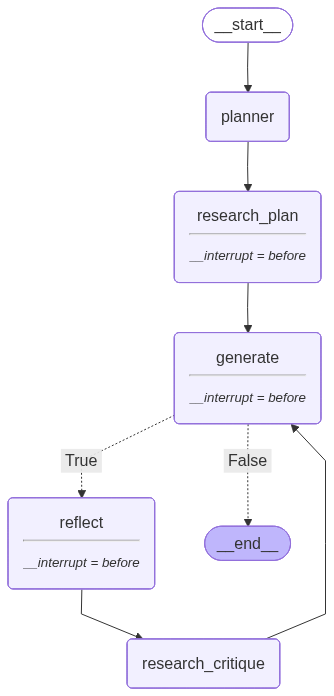

[OK] Graph rendered successfully as PNG.


In [12]:
# Cell 10: Graph visualization & structural inspection (Mermaid-aligned)
# ---------------------------------------------------------------------
# This cell provides an explicit visualization of the compiled StateGraph.
# Its purpose is not cosmetic — it is epistemic.
#
# Why this matters:
# - Makes agent orchestration legible (planner, researcher, writer, critic)
# - Exposes iteration loops and stopping conditions
# - Enables Human-in-the-Loop (HITL) debugging and validation
# - Serves as a cognitive map of the system's reasoning flow
#
# Rendering strategy:
# 1) Preferred: Render a PNG via Mermaid + Playwright (rich visualization)
# 2) Fallback: Output raw Mermaid syntax for manual inspection or external tools
#
# Note:
# Visualization is optional for execution, but critical for understanding,
# auditing, and teaching multi-agent systems.

from IPython.display import Image, display
import os

print("\n[Graph Inspection] Attempting to render StateGraph via Mermaid...")

try:
    # Attempt rich PNG rendering (requires playwright)
    graph_image = graph.get_graph().draw_mermaid_png()
    display(Image(data=graph_image))
    print("[OK] Graph rendered successfully as PNG.")

except Exception as e:
    print("[WARN] PNG rendering failed.")
    print(f"Reason: {e}")

    print("\n[Fallback] Attempting to generate Mermaid source code only...\n")

    try:
        mermaid_code = graph.get_graph().draw_mermaid()
        print("----- Mermaid Graph Definition -----\n")
        print(mermaid_code)
        print("\n------------------------------------")
        print(
            "Tip: Paste this code into https://mermaid.live/ "
            "or render it directly in Markdown-enabled notebooks."
        )

    except Exception as e_mermaid:
        print("[ERROR] Unable to generate Mermaid code.")
        print(f"Reason: {e_mermaid}")
        print(
            "Verify that the graph is compiled correctly and that "
            "`graph.get_graph()` is accessible."
        )

In [13]:
# Cell 11: Stream test (simple, no manual HITL — auto-resume)
# ----------------------------------------------------------------
# Simple runtime runner for the compiled graph. Designed for tests:
# - prints event keys and short previews
# - auto-resumes interrupts with a default 'approve' decision (no manual HITL)
# - prints final state summary and a short preview of generated content
#
# Edit `thread_config` or `input_state` as needed.

from pprint import pprint
import time
from langgraph.types import Command

# ----------------------------
# Config (edit values as desired)
# ----------------------------
thread_config = {"configurable": {"thread_id": "1"}}

input_state = {
    "task": "What is the difference between Langchain and Langsmith?",
    "max_revisions": 2,
    "revision_number": 1,
    "content": [],
}

# Auto-resume behavior: if graph emits __interrupt__, resume automatically
auto_resume_on_interrupt = True

# ----------------------------
# Helper: short event summarizer
# ----------------------------
def summarize_event(ev):
    keys = list(ev.keys())
    preview = {}
    for k, v in ev.items():
        if k == "__interrupt__":
            preview[k] = "<INTERRUPT>"
        else:
            try:
                if isinstance(v, dict) and "messages" in v:
                    preview[k] = {"messages": f"[{len(v['messages'])} items]"}
                else:
                    preview[k] = type(v).__name__
            except Exception:
                preview[k] = str(v)[:200]
    return {"keys": keys, "preview": preview}

# ----------------------------
# Run the stream
# ----------------------------
print("\n🚀 Starting streaming run for thread:", thread_config["configurable"]["thread_id"])
start_time = time.time()
last_event = None

try:
    for i, event in enumerate(graph.stream(input_state, thread_config)):
        last_event = event
        print("\n" + "=" * 60)
        print(f"Event #{i} -> keys:", list(event.keys()))
        pprint(summarize_event(event))

        # If interrupt occurs and auto-resume enabled, resume with a default 'approve'
        if "__interrupt__" in event:
            print("\n[⏸️] Graph paused with __interrupt__. Auto-resume is enabled.")
            decisions = [{"type": "approve"}]
            # resume and consume resumed events (non-blocking loop)
            for j, resumed_event in enumerate(graph.stream(Command(resume={"decisions": decisions}), config=thread_config)):
                print(f"\n--- Resumed event #{j} ---")
                pprint(summarize_event(resumed_event))
                last_event = resumed_event

except Exception as e:
    print(f"\n[❌] Error while streaming the graph: {e}")
    raise

elapsed = time.time() - start_time
print(f"\n✅ Stream finished in {elapsed:.2f}s")

# ----------------------------
# Final state summary (best-effort)
# ----------------------------
try:
    final_state_obj = graph.get_state(thread_config)
    print("\n--- Final state snapshot (summary) ---")
    if hasattr(final_state_obj, "values") and isinstance(final_state_obj.values, dict):
        summary = {}
        for k, v in final_state_obj.values.items():
            if isinstance(v, list):
                summary[k] = f"[{len(v)} items]"
            else:
                summary[k] = (v if not isinstance(v, str) else (v[:400] + "..." if len(v) > 400 else v))
        pprint(summary)
    else:
        pprint(final_state_obj)
except Exception as e:
    print(f"[WARN] Could not retrieve final state: {e}")

# ----------------------------
# Preview last messages (if any)
# ----------------------------
if last_event:
    # find node with messages
    for node_name, node_data in reversed(list(last_event.items())):
        if isinstance(node_data, dict) and "messages" in node_data:
            msgs = node_data["messages"]
            if msgs:
                print("\n--- Preview of last messages (up to 3) ---")
                for m in msgs[-3:]:
                    content = getattr(m, "content", None) or str(m)
                    print("-" * 80)
                    print(content[:1000])
            break

print("\n[ℹ️] Simple stream test completed.")


🚀 Starting streaming run for thread: 1
[values] {'task': 'What is the difference between Langchain and Langsmith?', 'plan': '**Essay Plan:**\n\nI. Introduction\n  - Introduce the topic of Langchain and Langsmith.\n  - Provide background information on both terms.\n\nII. Definition and Purpose\n  - Define Langchain and its primary function in AI development.\n  - Explain how Langchain enables users to interact with large language models (LLMs).\n  - Define Langsmith, its role in AI development, and how it differs from Langchain.\n\nIII. Key Differences\n  - Discuss the main differences between Langchain and Langsmith, including their capabilities and limitations.\n  - Provide examples or scenarios where each tool is more suitable than the other.\n\nIV. Conclusion\n  - Summarize the key points discussed in the essay.\n  - Offer recommendations for when to use Langchain versus Langsmith in AI development projects.\n\nThis plan provides a clear structure for an essay that compares and con